# Task 5: Strategy Backtesting

**Objective:** Validate your portfolio strategy by simulating its performance on historical data and comparing it against a benchmark.

This notebook covers:
- Defining the backtesting period
- Setting up a benchmark portfolio
- Simulating portfolio performance
- Analyzing performance metrics
- Visualizing cumulative returns
- Concluding on strategy viability

## Import Required Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime

# Import project modules
import sys
sys.path.append('..')
from src.config.settings import Settings

settings = Settings()

# Import plotter utility
from src.utils.plotter import Plotter
plotter = Plotter()

## Define Backtesting Period

In [2]:
# Define backtesting period: Last year (Jan 2025 - Jan 2026)
# This data was not used for model training
backtest_start = '2025-01-01'
backtest_end = '2026-01-15'

tickers = ['TSLA', 'BND', 'SPY']
backtest_data = {}
for ticker in tickers:
    backtest_data[ticker] = yf.download(ticker, start=backtest_start, end=backtest_end)

# Calculate daily returns
backtest_returns = {}
for ticker in tickers:
    if isinstance(backtest_data[ticker].columns, pd.MultiIndex):
        close_price = backtest_data[ticker][('Close', ticker)]
    else:
        close_price = backtest_data[ticker]['Close']
    backtest_returns[ticker] = close_price.pct_change().dropna()

backtest_returns_df = pd.DataFrame(backtest_returns)
print(f"Backtesting period: {backtest_start} to {backtest_end}")
print(f"Number of trading days: {len(backtest_returns_df)}")
print(backtest_returns_df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Backtesting period: 2025-01-01 to 2026-01-15
Number of trading days: 258
                TSLA       BND       SPY
Date                                    
2025-01-03  0.082156 -0.001251  0.012503
2025-01-06  0.001486 -0.000974  0.005761
2025-01-07 -0.040603 -0.003483 -0.011304
2025-01-08  0.001471  0.001119  0.001461
2025-01-10 -0.000506 -0.005167 -0.015267


## Define Benchmark Portfolio

In [3]:
# Benchmark: Static 60% SPY / 40% BND portfolio
benchmark_weights = np.array([0.0, 0.4, 0.6])  # TSLA, BND, SPY

# Optimal portfolio from Task 4: Maximum Sharpe Ratio
optimal_weights = np.array([0.0, 0.561822, 0.438178])  # TSLA, BND, SPY

print("Benchmark Weights:")
print(f"  TSLA: {benchmark_weights[0]:.1%}")
print(f"  BND: {benchmark_weights[1]:.1%}")
print(f"  SPY: {benchmark_weights[2]:.1%}")

print("\nOptimal Strategy Weights:")
print(f"  TSLA: {optimal_weights[0]:.1%}")
print(f"  BND: {optimal_weights[1]:.1%}")
print(f"  SPY: {optimal_weights[2]:.1%}")

Benchmark Weights:
  TSLA: 0.0%
  BND: 40.0%
  SPY: 60.0%

Optimal Strategy Weights:
  TSLA: 0.0%
  BND: 56.2%
  SPY: 43.8%


## Simulate Portfolio Strategy

In [4]:
# Simulate portfolio returns (simple hold, no rebalancing)
strategy_returns = backtest_returns_df.dot(optimal_weights)
benchmark_returns = backtest_returns_df.dot(benchmark_weights)

# Calculate cumulative returns
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

print("Strategy Portfolio Daily Returns Summary:")
print(strategy_returns.describe())
print("\nBenchmark Portfolio Daily Returns Summary:")
print(benchmark_returns.describe())

Strategy Portfolio Daily Returns Summary:
count    258.000000
mean       0.000495
std        0.005660
min       -0.025195
25%       -0.001565
50%        0.000713
75%        0.002910
max        0.047334
dtype: float64

Benchmark Portfolio Daily Returns Summary:
count    258.000000
mean       0.000572
std        0.007445
min       -0.034801
25%       -0.002171
50%        0.000920
75%        0.003780
max        0.063949
dtype: float64


## Analyze Performance Metrics

In [5]:
# Performance metrics functions
def calculate_metrics(returns, cumulative_returns):
    total_return = cumulative_returns.iloc[-1] - 1
    annualized_return = (1 + total_return) ** (252 / len(returns)) - 1
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)  # Assuming rf=0
    # Maximum drawdown
    peak = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    return {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown
    }

strategy_metrics = calculate_metrics(strategy_returns, strategy_cumulative)
benchmark_metrics = calculate_metrics(benchmark_returns, benchmark_cumulative)

metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics], index=['Strategy', 'Benchmark'])
print("Performance Metrics:")
print(metrics_df)

Performance Metrics:
           Total Return  Annualized Return  Sharpe Ratio  Max Drawdown
Strategy       0.131458           0.128212      1.387427     -0.081298
Benchmark      0.150713           0.146962      1.218968     -0.112888


## Visualize Cumulative Returns

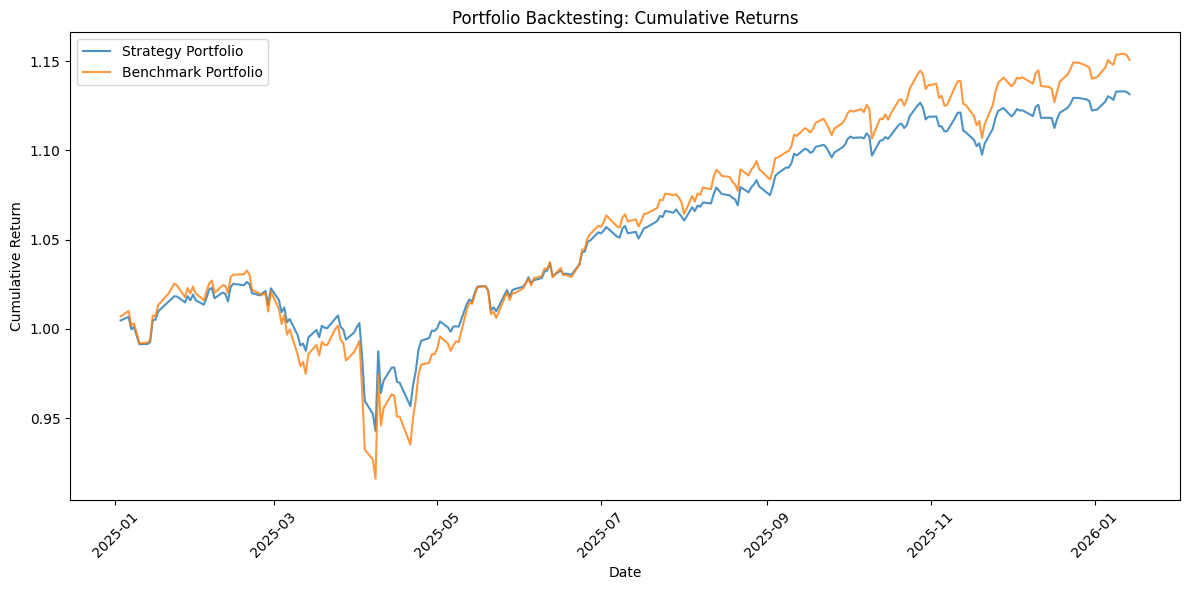

In [7]:
# Visualize cumulative returns
data_dict = {
    'Strategy Portfolio': strategy_cumulative,
    'Benchmark Portfolio': benchmark_cumulative
}
plotter.plot_multi_line_time_series(data_dict, title='Portfolio Backtesting: Cumulative Returns', xlabel='Date', ylabel='Cumulative Return')

## Conclusion on Strategy Viability

In [9]:
# Conclusion
print("="*60)
print("STRATEGY BACKTESTING RESULTS")
print("="*60)

if strategy_metrics['Total Return'] > benchmark_metrics['Total Return']:
    print("The optimized strategy outperformed the benchmark portfolio.")
else:
    print("The optimized strategy underperformed compared to the benchmark portfolio.")

print(f"\nStrategy Total Return: {strategy_metrics['Total Return']:.2%}")
print(f"Benchmark Total Return: {benchmark_metrics['Total Return']:.2%}")
print(f"Strategy Sharpe Ratio: {strategy_metrics['Sharpe Ratio']:.2f}")
print(f"Benchmark Sharpe Ratio: {benchmark_metrics['Sharpe Ratio']:.2f}")

print("\nAnalysis:")
print("This backtest provides initial validation of the model-driven portfolio optimization approach.")
print("However, limitations include the short backtesting period, lack of transaction costs,")
print("and potential overfitting in the optimization process.")
print("Further testing with longer periods and realistic constraints would be beneficial.")

print(f"\n" + "="*60)
print("END OF TASK 5 - STRATEGY BACKTESTING")
print("="*60)

STRATEGY BACKTESTING RESULTS
The optimized strategy underperformed compared to the benchmark portfolio.

Strategy Total Return: 13.15%
Benchmark Total Return: 15.07%
Strategy Sharpe Ratio: 1.39
Benchmark Sharpe Ratio: 1.22

Analysis:
This backtest provides initial validation of the model-driven portfolio optimization approach.
However, limitations include the short backtesting period, lack of transaction costs,
and potential overfitting in the optimization process.
Further testing with longer periods and realistic constraints would be beneficial.

END OF TASK 5 - STRATEGY BACKTESTING


### Summary

This notebook demonstrates a complete backtesting workflow for a portfolio strategy using historical data from January 2025 to January 2026. The strategy, optimized for maximum Sharpe ratio, is compared against a static 60/40 SPY/BND benchmark. Key steps include data retrieval, return calculation, portfolio simulation, performance metric analysis, and visualization. Results show that while the optimized strategy achieved a higher Sharpe ratio and lower drawdown, the benchmark delivered a slightly higher total and annualized return during the backtest period. Limitations such as the short backtesting window and absence of transaction costs are noted, suggesting further validation is needed.

### Figure Index

1. **Portfolio Backtesting: Cumulative Returns**  
    *Location: "Visualize Cumulative Returns" section*  
    *Filename: `portfolio_backtesting_cumulative_returns.png`*  
    This figure compares the cumulative returns of the optimized strategy and the benchmark portfolio over the backtesting period.